# Chapter 7: Control What Images to Generate in Diffusion Models

This chapter covers:

* Creating and training a conditional diffusion model to generate images you want
* Building a denoising U-Net from scratch
* Coding diffusion processes in a Denoising Diffusion Probabilistic Model (DDPM)
* Injecting labeling information and time steps into the U-Net model
* The idea of classifier-free guidance in training conditional and unconditional diffusion models simultaneously

In the previous chapter, you learned how to create a diffusion model from scratch to generate images of clothing items such as coats, bags, and sandals. There are ten different types of clothing items and the model randomly generates images from one of these ten types. You may be wondering, can I tell the model to generate the item I want, such as a sandal, a t-shirt, or a coat? It turns out you can.

In this chapter, you'll learn to create and train a diffusion model to take in the label of a clothing item as the conditioning information so that the model generates the image you want. This skill has far-reaching implications in later chapters. The goal of text-to-image generation is to create images based on text prompts. This requires the diffusion model to effectively incorporate the text description as the conditioning information and generate images that match this description. In this chapter, we will explore the mechanisms that allow a diffusion model to integrate this information, ensuring that the generated images accurately reflect the given conditioning label.

In the previous chapter, we treated the U-Net denoising model as a black box, relying on an out-of-the-box model from the diffusers library. This approach, while convenient, offers limited insight into the underlying workings of the model. In this chapter, we will peel back the layers of abstraction by constructing a denoising U-Net model from scratch. This hands-on approach gives us a chance to understand the structure of the model, particularly how to incorporate class labels and time step information through embedding.

Moreover, we will create from scratch a Denoising Diffusion Probabilistic Model (DDPM), which forms the backbone of our diffusion process. You will code both the forward diffusion and reverse diffusion processes, learning how noise is gradually added and then removed to generate coherent images.

Classifier-free guidance is a very important concept in text-to-image generation. In a 2022 paper, Jonathan Ho and Tim Salimans show that guidance can be performed by a pure generative model without a classifier.  They jointly train a conditional and unconditional diffusion model to attain a trade-off between sample quality and diversity. As you'll see later in this book, classifier-free guidance is a technique used to improve the quality of generated images in diffusion models. Traditional diffusion models use classifiers to guide the generation process. In contrast, classifier-free guidance bypasses the need for an external classifier by incorporating guidance within the model. The idea is to train the diffusion model both with and without conditioning information (class labels in this chapter; text prompts in later chapters). During training, sometimes the model is conditioned, and sometimes it is not. At inference time, guidance can be applied by interpolating between the conditional and unconditional predictions, allowing more controlled and more diverse image generation.

By the end of this chapter, you will know how to create a fully functional conditional diffusion model from scratch. This knowledge will guide you in your exploration of more complex text-to-image generation models in subsequent chapters.

# 1	Classifier-free guidance in diffusion models
## 1.1	An overview of classifier-free guidance
## 1.2	A blueprint to implement classifier-free guidance

# 2	Different components of a denoising U-Net model
## 2.1	Time step embedding and label embedding

The embedding block is defined as follows in the local module cfr_util.py.

```python
from torch import nn
class EmbedLayer(nn.Module):
    def __init__(self, input_dim, emb_dim):    #A
        super().__init__()
        self.input_dim = input_dim
        layers = [nn.Linear(input_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, emb_dim),]    #B
        self.model = nn.Sequential(*layers)
    def forward(self, x):
        x = x.view(-1, self.input_dim)
        return self.model(x)

```

In [1]:
import torch
from utils.cfr_util import EmbedLayer    #A

timeembed1=EmbedLayer(1, 512)    #B
timeembed2=EmbedLayer(1, 256)    #B

timesteps=torch.tensor([25]).long()    #C
t=timesteps/1000    #C
temb1 = timeembed1(t).view(-1, 512, 1, 1) 
temb2 = timeembed2(t).view(-1, 256, 1, 1) 
print("the shape of the first time embedding is", temb1.shape)    #D
print("the shape of the second time embedding is", temb2.shape)    #D

the shape of the first time embedding is torch.Size([1, 512, 1, 1])
the shape of the second time embedding is torch.Size([1, 256, 1, 1])


In [2]:
# answer to exercise 6.1
timesteps=torch.tensor([42]).long()    
t=timesteps/1000    
temb1 = timeembed1(t).view(-1, 512, 1, 1) 
temb2 = timeembed2(t).view(-1, 256, 1, 1) 
print("the shape of the first time embedding is", temb1.shape)    
print("the shape of the second time embedding is", temb2.shape)    

the shape of the first time embedding is torch.Size([1, 512, 1, 1])
the shape of the second time embedding is torch.Size([1, 256, 1, 1])


In [3]:
n_classes=10
contextembed1=EmbedLayer(n_classes, 512)    #A
contextembed2=EmbedLayer(n_classes, 256)    #A
label=torch.tensor([2, 9, 0]).long()    #B
context_mask = torch.bernoulli(
    torch.zeros_like(label)+0.1)    #C
onehot = torch.nn.functional.one_hot(label, 
            num_classes=n_classes).type(torch.float)    #D
context_mask = context_mask[:, None]
context_mask = context_mask.repeat(1,n_classes)
context_mask = (-1*(1-context_mask)) 
c = onehot * context_mask    
cemb1 = contextembed1(c).view(-1, 512, 1, 1) 
cemb2 = contextembed2(c).view(-1, 256, 1, 1) 
print("the shape of the first label embedding is", cemb1.shape)
print("the shape of the second label embedding is", cemb2.shape)

the shape of the first label embedding is torch.Size([3, 512, 1, 1])
the shape of the second label embedding is torch.Size([3, 256, 1, 1])


In [4]:
# answer to exercise 6.2
label=torch.tensor([1, 3, 5, 7]).long()    
context_mask = torch.bernoulli(
    torch.zeros_like(label)+0.1)    
onehot = torch.nn.functional.one_hot(label, 
            num_classes=n_classes).type(torch.float)    
context_mask = context_mask[:, None]
context_mask = context_mask.repeat(1,n_classes)
context_mask = (-1*(1-context_mask)) 
c = onehot * context_mask    
cemb1 = contextembed1(c).view(-1, 512, 1, 1) 
cemb2 = contextembed2(c).view(-1, 256, 1, 1) 
print("the shape of the first label embedding is", cemb1.shape)
print("the shape of the second label embedding is", cemb2.shape)

the shape of the first label embedding is torch.Size([4, 512, 1, 1])
the shape of the second label embedding is torch.Size([4, 256, 1, 1])


## 2.2	The U-Net denoising model architecture

## 2.3	Down blocks and up blocks in the U-Net

In [5]:
import torch 

img = torch.Tensor([[0,1,2,3],
                    [1,2,3,4],
                    [5,4,3,2],
                    [3,4,7,6]]).reshape(1,1,4,4)    #A

In [6]:
maxpool = torch.nn.MaxPool2d(2)    
out=maxpool(img)    
print(out)    

tensor([[[[2., 4.],
          [5., 7.]]]])


In [7]:
# answer to exercise 6.3
img2 = torch.Tensor([[8,1,9,3],
                    [1,2,3,4],
                    [5,6,3,2],
                    [3,4,7,8]]).reshape(1,1,4,4)      
out2=maxpool(img2)    
print(out2) 

tensor([[[[8., 9.],
          [6., 8.]]]])


In [8]:
image = torch.Tensor([[0,1],
                      [1,2]]).reshape(1,1,2,2)

In [9]:
transconv=torch.nn.ConvTranspose2d(in_channels=1,
            out_channels=1,
            kernel_size=2, 
            stride=2)    #A
sd=transconv.state_dict()
weights={'weight':torch.tensor([[[[1,2],
   [2,3]]]]), 'bias':torch.tensor([0])}
for k in sd:
    with torch.no_grad():
        sd[k].copy_(weights[k])    #B

In [10]:
transoutput = transconv(image)
print(transoutput)

tensor([[[[0., 0., 1., 2.],
          [0., 0., 2., 3.],
          [1., 2., 2., 4.],
          [2., 3., 4., 6.]]]], grad_fn=<ConvolutionBackward0>)


In [11]:
# answer to exercise 6.4
image = torch.Tensor([[3,2],
                      [5,4]]).reshape(1,1,2,2)
transconv=torch.nn.ConvTranspose2d(in_channels=1,
            out_channels=1,
            kernel_size=2, 
            stride=2)    
sd=transconv.state_dict()
weights={'weight':torch.tensor([[[[1,2],
   [2,3]]]]), 'bias':torch.tensor([0])}
for k in sd:
    with torch.no_grad():
        sd[k].copy_(weights[k])    
transoutput = transconv(image)
print(transoutput)

tensor([[[[ 3.,  6.,  2.,  4.],
          [ 6.,  9.,  4.,  6.],
          [ 5., 10.,  4.,  8.],
          [10., 15.,  8., 12.]]]], grad_fn=<ConvolutionBackward0>)


# 3.    Build a U-Net from Scratch
You'll learn to create a denoising U-Net model from scratch in this section. Further, you'll implement label embedding and time embedding in the U-Net model so that the U-Net model can denoise conditional on both time steps and the label of the clothing item. We'll also discuss how to code the classifier-free guidance and how to choose the strength of the generative guidance.

The Python code in this chapter is adapted from the excellent GitHub project by Tim Pearce https://github.com/TeaPearce/Conditional_Diffusion_MNIST.  For brevity, we use a local module to construct the U-Net and the noise scheduler. Download the file cfr_util.py from the book’s GitHub repository https://github.com/markhliu/txt2img and place it in the /utils/ folder on your computer. 

## 3.1 Build the denoising U-Net


The down block is define as follows in the local module: 

```python
class UnetDown(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        layers = [ResidualConvBlock(in_channels, 
                out_channels), nn.MaxPool2d(2)]
        self.model = nn.Sequential(*layers)
    def forward(self, x):
        return self.model(x)
```

The up block is defined in the local module: 

```python
class UnetUp(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        layers = [nn.ConvTranspose2d(in_channels,
                                     out_channels, 2, 2),
            ResidualConvBlock(out_channels, out_channels),
            ResidualConvBlock(out_channels, out_channels),]
        self.model = nn.Sequential(*layers)
    def forward(self, x, skip):
        x = torch.cat((x, skip), 1)
        x = self.model(x)
        return x
```    

```python
class Unet(nn.Module):
    def __init__(self, in_channels, n_feat = 256, n_classes=10):
        super().__init__()
        self.in_channels = in_channels
        self.n_feat = n_feat
        self.n_classes = n_classes
        self.init_conv = ResidualConvBlock(in_channels,
                               n_feat, is_res=True)
        self.down1 = UnetDown(n_feat, n_feat)
        self.down2 = UnetDown(n_feat, 2 * n_feat)
        self.to_vec = nn.Sequential(nn.AvgPool2d(7), nn.GELU())
        self.timeembed1 = EmbedLayer(1, 2*n_feat)
        self.timeembed2 = EmbedLayer(1, 1*n_feat)
        self.contextembed1 = EmbedLayer(n_classes, 2*n_feat)
        self.contextembed2 = EmbedLayer(n_classes, 1*n_feat)
        self.up0=nn.Sequential(nn.ConvTranspose2d(2*n_feat,2*n_feat,7,7), 
            nn.GroupNorm(8, 2 * n_feat),nn.ReLU(),)
        self.up1 = UnetUp(4 * n_feat, n_feat)
        self.up2 = UnetUp(2 * n_feat, n_feat)
        self.out = nn.Sequential(nn.Conv2d(2 * n_feat, n_feat, 3, 1, 1),
            nn.GroupNorm(8, n_feat),nn.ReLU(),
            nn.Conv2d(n_feat, self.in_channels, 3, 1, 1),)
    def forward(self, x, c, t, context_mask):
        x = self.init_conv(x)
        down1 = self.down1(x)
        down2 = self.down2(down1)
        hiddenvec = self.to_vec(down2)
        c=nn.functional.one_hot(c,num_classes=self.n_classes).type(torch.float)
        context_mask = context_mask[:, None]
        context_mask = context_mask.repeat(1,self.n_classes)
        context_mask = (-1*(1-context_mask)) 
        c = c * context_mask
        cemb1 = self.contextembed1(c).view(-1, self.n_feat * 2, 1, 1)
        temb1 = self.timeembed1(t).view(-1, self.n_feat * 2, 1, 1)
        cemb2 = self.contextembed2(c).view(-1, self.n_feat, 1, 1)
        temb2 = self.timeembed2(t).view(-1, self.n_feat, 1, 1)
        up1 = self.up0(hiddenvec)
        up2 = self.up1(cemb1*up1+ temb1, down2)  
        up3 = self.up2(cemb2*up2+ temb2, down1)
        out = self.out(torch.cat((up3, x), 1))
        return out
```    

## 3.2 The Denoising Diffusion Probabilistic Model (DDPM)


```python
device="cuda" if torch.cuda.is_available() else "cpu"
class DDPM(nn.Module):
    def __init__(self, model, n_T, device=device, drop_prob=0.1):
        super().__init__()
        self.model = model.to(device)
        for k, v in noise_scheduler(n_T).items():
            self.register_buffer(k, v)
        self.n_T = n_T
        self.device = device
        self.drop_prob = drop_prob
        self.loss_mse = nn.MSELoss()
    def forward(self, x, c):
        _ts=torch.randint(1,self.n_T+1,(x.shape[0],)).to(self.device)  
        noise = torch.randn_like(x)  
        x_t = (self.sqrtab[_ts, None, None, None] * x
            + self.sqrtmab[_ts, None, None, None] * noise)  
        context_mask = torch.bernoulli(torch.zeros_like(c)+
                                   self.drop_prob).to(self.device)
        return self.loss_mse(noise, 
                 self.model(x_t, c, _ts / self.n_T, context_mask))
```    

```python
import numpy as np 

@torch.no_grad()
def sample(ddpm, model, n_sample, size, device, 
           guide_w = 0.0, step_size=1):
    x_i = torch.randn(n_sample, *size).to(device) 
    c_i = torch.arange(0,10).to(device) 
    c_i = c_i.repeat(int(n_sample/c_i.shape[0]))
    context_mask = torch.zeros_like(c_i).to(device)
    c_i = c_i.repeat(2)
    context_mask = context_mask.repeat(2)
    # The second half of the labels are masked
    context_mask[n_sample:] = 1. 
    x_i_store = [] 
    for i in range(ddpm.n_T, 0, -step_size):
        t_is = torch.tensor([i / ddpm.n_T]).to(device)
        t_is = t_is.repeat(n_sample,1,1,1)
        x_i = x_i.repeat(2,1,1,1)
        t_is = t_is.repeat(2,1,1,1)
        z = torch.randn(n_sample,*size).to(device) if i>1 else 0
        eps = model(x_i, c_i, t_is, context_mask)
        # conditional generation
        eps1 = eps[:n_sample]
        # unconditional generation
        eps2 = eps[n_sample:]
        # output is a mix of conditional and unconditional generation
        eps = (1+guide_w)*eps1 - guide_w*eps2
        x_i = x_i[:n_sample]
        x_i = (ddpm.oneover_sqrta[i] * (x_i - 
                    eps * ddpm.mab_over_sqrtmab[i])
            + ddpm.sqrt_beta_t[i] * z)
        if i%20==0 or i==ddpm.n_T or i<8:
            x_i_store.append(x_i.detach().cpu().numpy())
    x_i_store = np.array(x_i_store)
    return x_i, x_i_store
```

The sample() function follows the guidance sampling scheme described in the 2022 paper by Ho and Salimans. We create two versions of the generated datasets: one set from conditional generation and the other from unconditional generation. The output is a mix of conditional and unconditional generation. The parameter guide_w controls the strength of the label guidance in generation. 

The step_size parameter controls how many reference steps is used in image generation, with a default value of step_size=1. When generating images, we go from time step 1000 to 0, skipping step_size time steps. Therefore, when step_size=1, there are 1000 reference steps. When step_size=2, there are 500 reference steps. When step_size=5, there are 200 reference steps, and so on. There is a trade-off: more reference time steps lead to better image quality, but it takes longer to generate the images. 

## 3.3 Train the Diffusion Model


In [12]:
from torchvision import transforms, datasets

torch.manual_seed(42)
tf = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Lambda(lambda x: 2*(x-0.5)),])    #A
dataset = datasets.FashionMNIST(
    r".",
    train=True,
    download=True,
    transform=tf,)    #B

In [13]:
text_labels=['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']

In [14]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

In [15]:
from utils.cfr_util import Unet, DDPM

n_epoch = 20
n_T = 1000
device="cuda" if torch.cuda.is_available() else "cpu"
n_classes = 10
n_feat = 256
lrate=0.0001
model=Unet(in_channels=1,
           n_feat=n_feat,
           n_classes=n_classes)    #A
ddpm=DDPM(model, n_T=n_T).to(device)    #B
optim = torch.optim.Adam(ddpm.parameters(), lr=lrate)

We can now train the model as follows:

In [16]:
from tqdm import tqdm
scaler = torch.amp.GradScaler("cuda")
for ep in range(n_epoch):
    print(f'epoch {ep}')
    ddpm.train()
    optim.param_groups[0]["lr"]=lrate*(1-ep/n_epoch)
    pbar=tqdm(dataloader)
    loss_ema=None
    for x, c in pbar:    #A 
        x = x.to(device)
        c = c.to(device)
        with torch.amp.autocast("cuda"):
            loss = ddpm(x,c)    #B
        optim.zero_grad() 
        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()    
        if loss_ema is None:
            loss_ema = loss.item()
        else:
            loss_ema = 0.95 * loss_ema + 0.05 * loss.item()                
        pbar.set_description(f"loss: {loss_ema:.4f}")
        optim.step()    #C
torch.save(model.state_dict(),"files/conditional.pth")    #D

The above training takes less than an hour with GPU training. Alternatively, you can download the trained model from my Google Drive https://drive.google.com/file/d/1Bh1RXHDAvsl5FEuUin9ywl1q9O3QDDmK/view?usp=sharing. Unzip the file after downloading and place it in the /files/ folder on your computer.

# 4. Generate Images with the Trained Conditional Diffusion Model


## 4.1 Visualize Generated Images in Different Time Steps


In [17]:
from utils.cfr_util import sample
model.load_state_dict(torch.load("files/conditional.pth",
            weights_only=True,
            map_location=device))    #A 
x,c=next(iter(dataloader))
x,c=x.to(device),c.to(device)
ddpm.eval()
n_sample = n_classes
x_gen,x_gen_store=sample(ddpm,model,n_sample,(1,28,28),
            device,guide_w=2)    #B
x_real = torch.Tensor(x_gen.shape).to(device)    #C
for k in range(n_classes):
    try: 
        idx = torch.squeeze((c == k).nonzero())[0]
    except:
        idx = 0
    x_real[k] = x[idx]
x_all = torch.cat([x_gen, x_real])


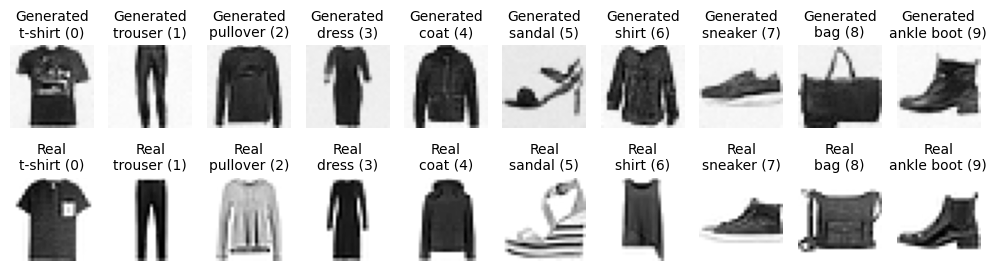

In [18]:
# create captions for each image
captions=[]
for i in range(20):
    gen="Generated" if i<10 else "Real"
    num=i%10
    label_and_num=f"{gen}\n{text_labels[num]} ({num})"
    captions.append(label_and_num)

# plot generated images on top and real images at the bottom
from matplotlib import pyplot as plt

plt.figure(figsize=(10,3),dpi=100)
for i in range(20):
    plt.subplot(2,10,i+1)
    plt.imshow(x_all[i].cpu().permute(1,2,0)/2+0.5,
               cmap="binary")
    plt.axis('off')
    plt.title(captions[i],fontsize=10)
plt.tight_layout()
plt.show()

As you can see, the generated images match the label, and they resemble the real images from teh training set. 

## 4.2 How the guidance parameter affect the generated images


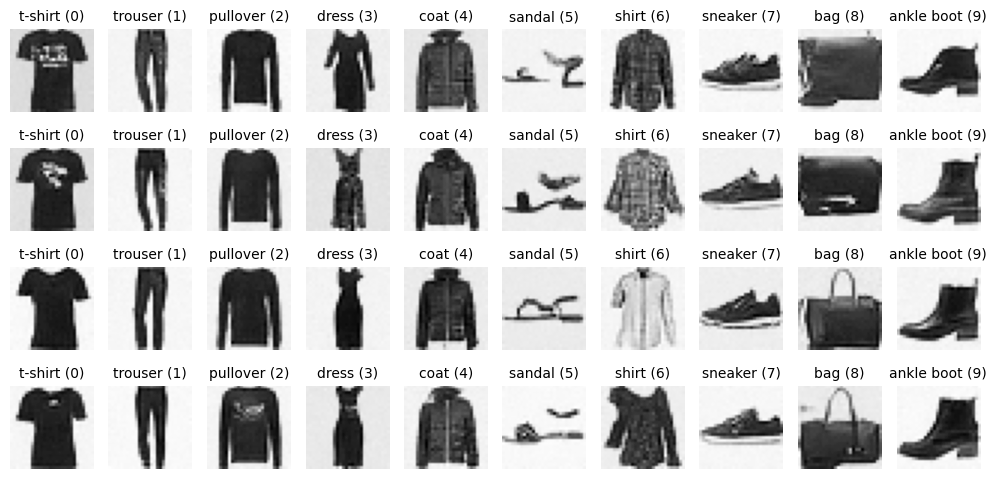

In [19]:
n_sample  = 4*n_classes
x_gen,x_gen_store=sample(ddpm,model,n_sample,(1,28,28),
                              device,guide_w=5)    #A
plt.figure(figsize=(10,5),dpi=100)
for i in range(40):    #B
    plt.subplot(4,10,i+1)
    plt.imshow(x_gen[i].cpu().permute(1,2,0)/2+0.5,
               cmap="binary")
    plt.axis('off')
    c=i%10
    plt.title(f"{text_labels[c]} ({c})",fontsize=10)
plt.tight_layout()
plt.show()


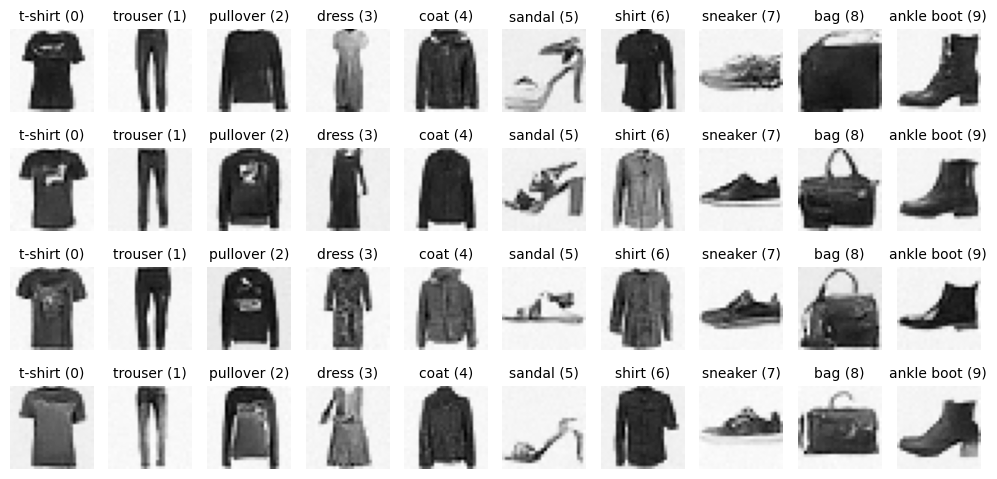

In [20]:
# exercise 6.5
n_sample  = 4*n_classes
x_gen,x_gen_store=sample(ddpm,model,n_sample,(1,28,28),
                              device,guide_w=1)    #A
plt.figure(figsize=(10,5),dpi=100)
for i in range(40):    #B
    plt.subplot(4,10,i+1)
    plt.imshow(x_gen[i].cpu().permute(1,2,0)/2+0.5,
               cmap="binary")
    plt.axis('off')
    c=i%10
    plt.title(f"{text_labels[c]} ({c})",fontsize=10)
plt.tight_layout()
plt.show()
